# 01. Analisi Esplorativa dei Dati (EDA) e Preprocessing
Questo notebook carica il dataset FER-2013 pre-salvato come archivio NumPy, analizza le statistiche di base, mostra la distribuzione delle classi per ciascuno split (Train, Val, Test) e visualizza alcune immagini di esempio per ciascuna emozione.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Impostiamo lo stile dei grafici
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
# Carichiamo il dataset
data_path = "../data/fer2013.npz"
if not os.path.exists(data_path):
    data_path = "data/fer2013.npz"

data = np.load(data_path)

X_train, y_train = data["train_images"], data["train_labels"]
X_val, y_val = data["val_images"], data["val_labels"]
X_test, y_test = data["test_images"], data["test_labels"]

print("Dimensioni dei dati caricati:")
print(f"Train - Immagini: {X_train.shape}, Etichette: {y_train.shape}")
print(f"Val   - Immagini: {X_val.shape}, Etichette: {y_val.shape}")
print(f"Test  - Immagini: {X_test.shape}, Etichette: {y_test.shape}")

Dimensioni dei dati caricati:
Train - Immagini: (25117, 48, 48), Etichette: (25117,)
Val   - Immagini: (5380, 48, 48), Etichette: (5380,)
Test  - Immagini: (5390, 48, 48), Etichette: (5390,)


In [3]:
# Definiamo la mappatura delle emozioni in italiano e inglese
EMOTIONS = {
    0: "Rabbia (Angry)",
    1: "Disgusto (Disgust)",
    2: "Paura (Fear)",
    3: "Felicità (Happy)",
    4: "Tristezza (Sad)",
    5: "Sorpresa (Surprise)",
    6: "Neutro (Neutral)"
}

emotion_names = [EMOTIONS[i] for i in range(7)]

## Distribuzione delle Classi (Emozioni)
Analizziamo lo sbilanciamento delle classi nei tre diversi split per verificare che la distribuzione sia consistente.

In [4]:
# Creiamo un DataFrame per la visualizzazione delle frequenze
df_train = pd.DataFrame({"Emozione": [EMOTIONS[y] for y in y_train], "Split": "Train"})
df_val = pd.DataFrame({"Emozione": [EMOTIONS[y] for y in y_val], "Split": "Val"})
df_test = pd.DataFrame({"Emozione": [EMOTIONS[y] for y in y_test], "Split": "Test"})

df_all = pd.concat([df_train, df_val, df_test])

# Conteggio delle classi
counts = df_all.groupby(["Split", "Emozione"]).size().unstack(level=0)
counts = counts.reindex(emotion_names)
print("Numero di campioni per classe e split:")
print(counts)

# Calcoliamo le percentuali
percentages = counts.div(counts.sum(axis=0), axis=1) * 100
print("\nDistribuzione percentuale (%) per split:")
print(percentages.round(2))

Numero di campioni per classe e split:
Split                Test  Train   Val
Emozione                              
Rabbia (Angry)        744   3467   742
Disgusto (Disgust)     83    382    82
Paura (Fear)          769   3584   768
Felicità (Happy)     1349   6292  1348
Tristezza (Sad)       913   4253   911
Sorpresa (Surprise)   601   2801   600
Neutro (Neutral)      931   4338   929

Distribuzione percentuale (%) per split:
Split                 Test  Train    Val
Emozione                                
Rabbia (Angry)       13.80  13.80  13.79
Disgusto (Disgust)    1.54   1.52   1.52
Paura (Fear)         14.27  14.27  14.28
Felicità (Happy)     25.03  25.05  25.06
Tristezza (Sad)      16.94  16.93  16.93
Sorpresa (Surprise)  11.15  11.15  11.15
Neutro (Neutral)     17.27  17.27  17.27


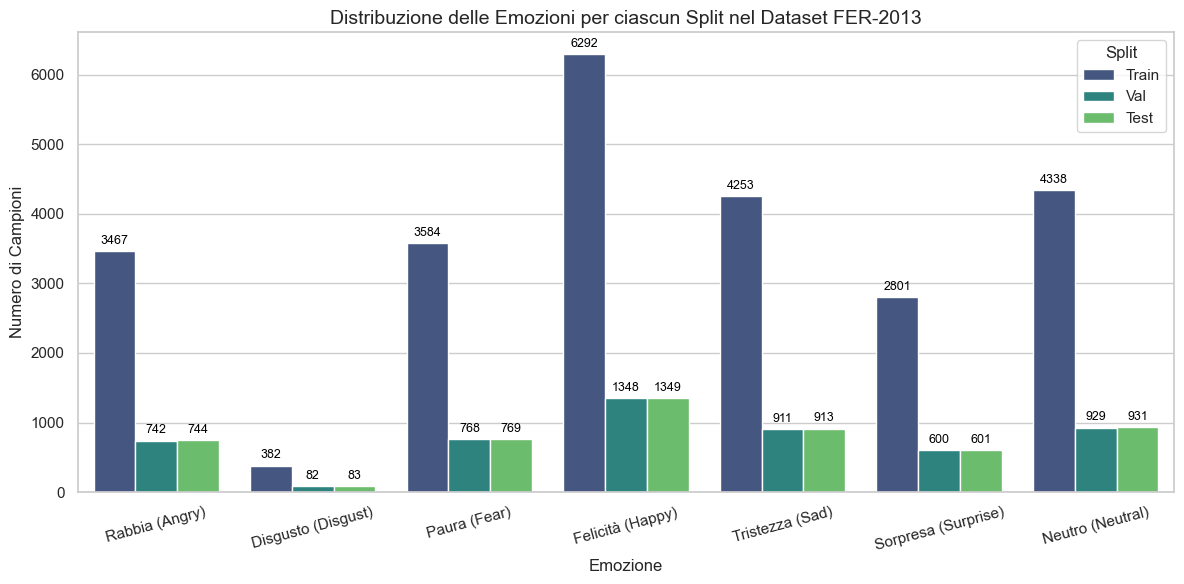

In [5]:
# Grafico a barre della distribuzione delle classi
plt.figure(figsize=(12, 6))
ax = sns.countplot(
    data=df_all, 
    x="Emozione", 
    hue="Split", 
    order=emotion_names,
    palette="viridis"
)
plt.title("Distribuzione delle Emozioni per ciascun Split nel Dataset FER-2013", fontsize=14)
plt.xlabel("Emozione", fontsize=12)
plt.ylabel("Numero di Campioni", fontsize=12)
plt.xticks(rotation=15)
plt.legend(title="Split")

# Aggiunge i valori sopra le barre
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{int(height)}',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            fontsize=9, color='black',
            xytext=(0, 3),
            textcoords='offset points'
        )

plt.tight_layout()
plt.show()

## Visualizzazione delle Immagini del Volto
Mostriamo una griglia di immagini per ciascuna delle 7 emozioni per ispezionare visivamente la qualità dei volti ed eventuali rumori/ambiguità nei dati.

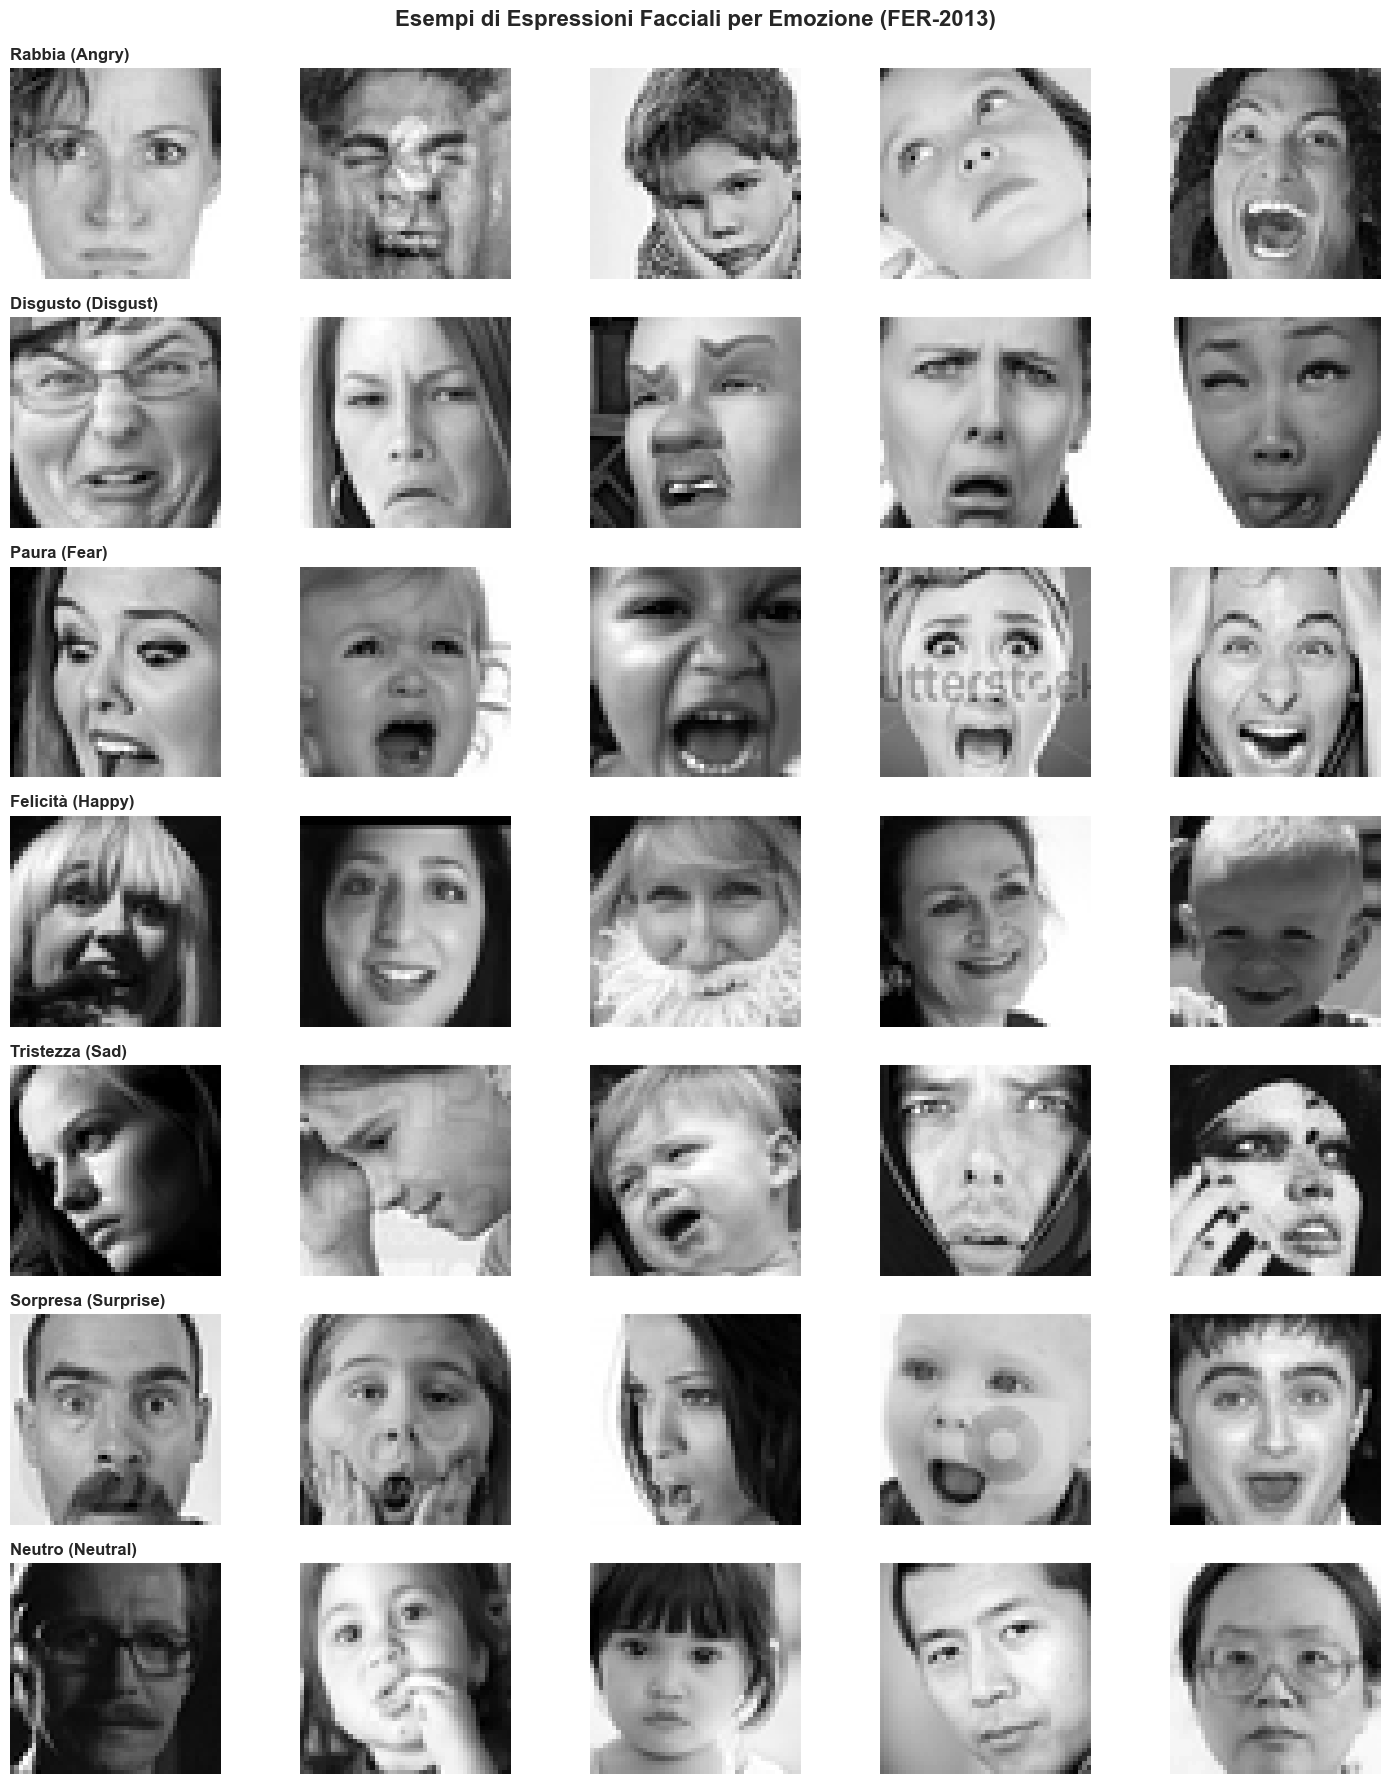

In [6]:
# Grid di immagini di esempio
n_examples = 5
fig, axes = plt.subplots(7, n_examples, figsize=(15, 18))

for emotion_idx, emotion_name in EMOTIONS.items():
    # Troviamo gli indici corrispondenti a questa emozione nel training set
    indices = np.where(y_train == emotion_idx)[0]
    # Selezioniamo casualmente n_examples
    np.random.seed(42) # per riproducibilità
    selected_indices = np.random.choice(indices, n_examples, replace=False)
    
    for col_idx, img_idx in enumerate(selected_indices):
        ax = axes[emotion_idx, col_idx]
        img = X_train[img_idx]
        ax.imshow(img, cmap='gray')
        ax.axis('off')
        
        if col_idx == 0:
            ax.set_title(emotion_name, loc='left', fontweight='bold', fontsize=12)

plt.suptitle("Esempi di Espressioni Facciali per Emozione (FER-2013)", fontsize=16, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()

## Conclusioni dell'EDA
1. **Risoluzione e Colore**: Le immagini sono 48x48 pixel in scala di grigi.
2. **Sbilanciamento delle Classi**: La classe *Felicità (Happy)* è la più rappresentata (~25% in tutti gli split), mentre la classe *Disgusto (Disgust)* è fortemente sottorappresentata (~1.5%). Questo sbilanciamento dovrà essere tenuto in considerazione nell'addestramento dei modelli (ad es. usando pesi di classe o metriche di valutazione pesate come l'F1-score invece della sola accuratezza).
3. **Distribuzione degli Split**: Gli split di Train, Validation e Test hanno percentuali di classi molto simili, garantendo una valutazione coerente ed equa dei modelli.
4. **Rumorosità dei Dati**: Alcune immagini mostrano occlusioni parziali (mani sul volto, occhiali da sole), scritte o disegni sovrapposti, o angolazioni estreme. Questo rende FER-2013 un dataset "in the wild" realistico e stimolante per gli algoritmi di computer vision.